# Vanilla GAN for MNIST Digit Generation



In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models

# Make the experiment reproducible.
np.random.seed(42)
tf.random.set_seed(42)

# Print TensorFlow version to confirm the runtime environment.
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Load and Preprocess the Dataset

The Generator will use a `tanh` activation in its final layer, which produces values in the range `[-1, 1]`. Therefore, the real MNIST images are also scaled to the same range.

In [5]:
# Load MNIST images. Labels are not needed because this is an unconditional Vanilla GAN.
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Convert images from unsigned integers to floating point values.
x_train = x_train.astype("float32")

# Scale pixel values from [0, 255] to [-1, 1].
x_train = (x_train - 127.5) / 127.5

# Flatten each 28x28 image into a vector of 784 values.
# A basic Vanilla GAN commonly uses dense layers instead of convolutional layers.
x_train = x_train.reshape(x_train.shape[0], 784)

print("Training data shape:", x_train.shape)
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Training data shape: (60000, 784)
Minimum pixel value: -1.0
Maximum pixel value: 1.0


## 3. Define Hyperparameters


In [6]:
# Size of the random noise vector used as input to the Generator.
LATENT_DIM = 100

# Number of images processed in one training step.
BATCH_SIZE = 128

# Number of full passes over the training dataset.
EPOCHS = 10

# Learning rate for both Generator and Discriminator optimizers.
LEARNING_RATE = 0.0002

# Adam beta_1 value commonly used in GAN training.
BETA_1 = 0.5

# Number of generated images to display after selected epochs.
NUM_EXAMPLES_TO_GENERATE = 16

## 4. Build the Generator

The Generator receives a random noise vector and transforms it into a synthetic 28x28 image represented as a flattened vector of 784 pixel values.

In [7]:
def build_generator(latent_dim):
    """Builds the Generator model for a Vanilla GAN."""
    model = models.Sequential(name="Generator")

    # The Generator starts from random noise and expands it through dense layers.
    model.add(layers.Input(shape=(latent_dim,)))
    model.add(layers.Dense(256))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.BatchNormalization(momentum=0.8))

    model.add(layers.Dense(512))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.BatchNormalization(momentum=0.8))

    model.add(layers.Dense(1024))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.BatchNormalization(momentum=0.8))

    # The output layer has 784 units, one for each pixel in a 28x28 image.
    # tanh is used so generated values fall in the range [-1, 1].
    model.add(layers.Dense(784, activation="tanh"))

    return model


generator = build_generator(LATENT_DIM)
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       803,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,493,520 (5.70 MB)

 Trainable params: 1,489,936 (5.68 MB)

 Non-trainable params: 3,584 (14.00 KB)

## 5. Build the Discriminator

The Discriminator receives a flattened 28x28 image and predicts whether the image is real or generated.

In [8]:
def build_discriminator():
    """Builds the Discriminator model for a Vanilla GAN."""
    model = models.Sequential(name="Discriminator")

    # The Discriminator receives flattened image vectors with 784 values.
    model.add(layers.Input(shape=(784,)))
    model.add(layers.Dense(512))
    model.add(layers.LeakyReLU(negative_slope=0.2))

    model.add(layers.Dense(256))
    model.add(layers.LeakyReLU(negative_slope=0.2))

    # A single sigmoid output gives the probability that the image is real.
    model.add(layers.Dense(1, activation="sigmoid"))

    return model


discriminator = build_discriminator()
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Configure Loss Functions and Optimizers

The Discriminator is trained to classify real images as 1 and generated images as 0.

The Generator is trained through the Discriminator. Its objective is to make the Discriminator classify generated images as real.

In [9]:
# Binary cross-entropy is the standard loss for the original GAN formulation.
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

# Separate optimizers are used because the Generator and Discriminator are trained separately.
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1)


def discriminator_loss(real_output, fake_output):
    """Calculates how well the Discriminator separates real and fake images."""
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss


def generator_loss(fake_output):
    """Calculates how well the Generator fools the Discriminator."""
    return cross_entropy(tf.ones_like(fake_output), fake_output)

## 7. Prepare the Training Dataset

The TensorFlow Dataset API is used to shuffle and batch the training images efficiently.

In [10]:
train_dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(buffer_size=x_train.shape[0])
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print("Number of batches per epoch:", tf.data.experimental.cardinality(train_dataset).numpy())

Number of batches per epoch: 468


## 8. Define the Training Step

Each training step performs two updates:

1. Update the Discriminator using real images and generated images.
2. Update the Generator using feedback from the Discriminator.

In [11]:
@tf.function
def train_step(real_images):
    """Runs one GAN training step for a batch of real images."""
    batch_size = tf.shape(real_images)[0]

    # Random noise is the Generator input.
    noise = tf.random.normal([batch_size, LATENT_DIM])

    # GradientTape records operations so gradients can be calculated.
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generate fake images from random noise.
        generated_images = generator(noise, training=True)

        # Discriminator predictions for real and generated images.
        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # Calculate losses for both models.
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # Calculate gradients for each model.
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # Apply gradients to update model weights.
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

## 9. Helper Function to Display Generated Images

This function uses a fixed set of noise vectors so that image quality can be compared across epochs.

In [12]:
# Fixed seed images make progress easier to compare over time.
seed_noise = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, LATENT_DIM])


def display_generated_images(model, epoch, test_input):
    """Displays a grid of images generated from fixed noise vectors."""
    predictions = model(test_input, training=False)

    # Convert generated images from [-1, 1] back to [0, 1] for plotting.
    predictions = (predictions + 1.0) / 2.0
    predictions = tf.reshape(predictions, [-1, 28, 28])

    plt.figure(figsize=(6, 6))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i], cmap="gray")
        plt.axis("off")

    plt.suptitle(f"Generated Images After Epoch {epoch}")
    plt.tight_layout()
    plt.show()

## 10. Train the Vanilla GAN

Training GANs can be unstable because the Generator and Discriminator are learning against each other. Loss values may fluctuate, so visual inspection is often more useful than expecting a smooth loss curve.

Epoch 01/10 | Generator Loss: 1.9610 | Discriminator Loss: 0.6277


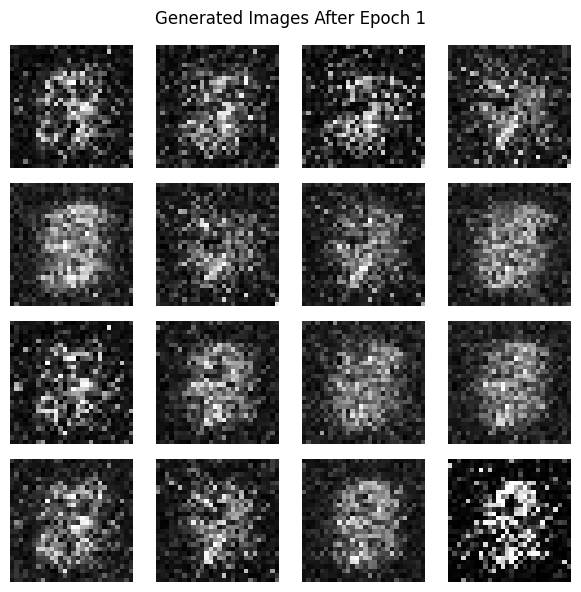

Epoch 02/10 | Generator Loss: 0.7294 | Discriminator Loss: 1.2715
Epoch 03/10 | Generator Loss: 0.8091 | Discriminator Loss: 1.2304
Epoch 04/10 | Generator Loss: 0.9319 | Discriminator Loss: 1.1261
Epoch 05/10 | Generator Loss: 0.9574 | Discriminator Loss: 1.1044


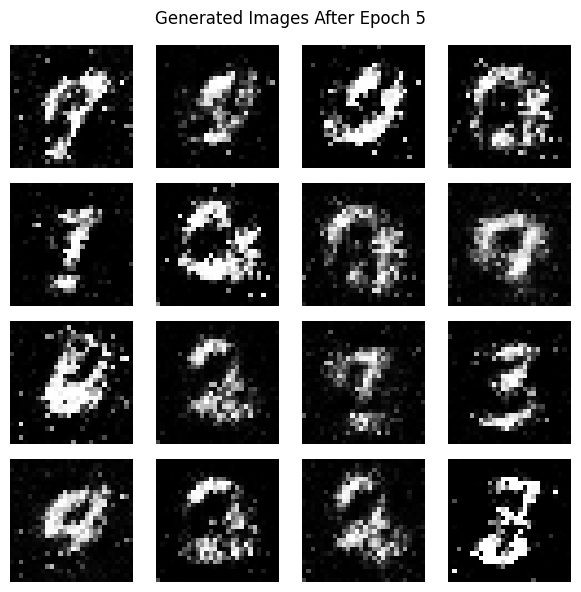

Epoch 06/10 | Generator Loss: 0.9697 | Discriminator Loss: 1.1079
Epoch 07/10 | Generator Loss: 0.9082 | Discriminator Loss: 1.1638
Epoch 08/10 | Generator Loss: 0.8589 | Discriminator Loss: 1.2191
Epoch 09/10 | Generator Loss: 0.8367 | Discriminator Loss: 1.2477
Epoch 10/10 | Generator Loss: 0.8440 | Discriminator Loss: 1.2364


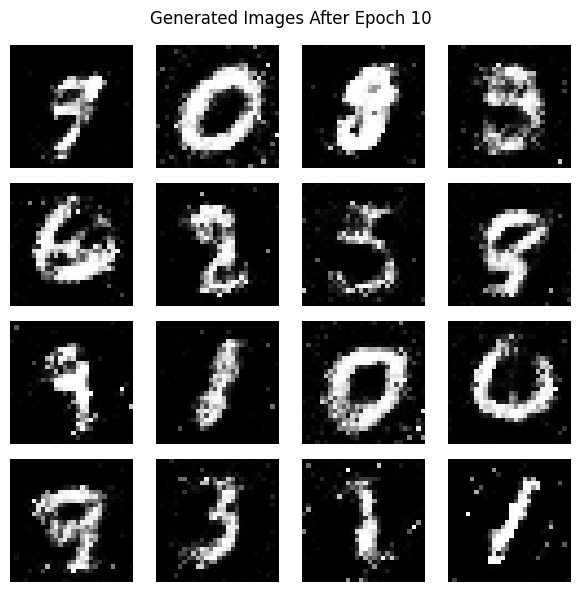

In [13]:
def train(dataset, epochs):
    """Trains the Vanilla GAN and displays generated images after selected epochs."""
    generator_losses = []
    discriminator_losses = []

    for epoch in range(1, epochs + 1):
        epoch_gen_losses = []
        epoch_disc_losses = []

        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)
            epoch_gen_losses.append(gen_loss.numpy())
            epoch_disc_losses.append(disc_loss.numpy())

        avg_gen_loss = float(np.mean(epoch_gen_losses))
        avg_disc_loss = float(np.mean(epoch_disc_losses))
        generator_losses.append(avg_gen_loss)
        discriminator_losses.append(avg_disc_loss)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Generator Loss: {avg_gen_loss:.4f} | "
            f"Discriminator Loss: {avg_disc_loss:.4f}"
        )

        # Display images at the first epoch, every 5 epochs, and the final epoch.
        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            display_generated_images(generator, epoch, seed_noise)

    return generator_losses, discriminator_losses


generator_losses, discriminator_losses = train(train_dataset, EPOCHS)

## 11. Plot Training Losses

The loss curves provide a basic view of training behavior. In GANs, the losses do not always decrease smoothly because each model is continuously adapting to the other.

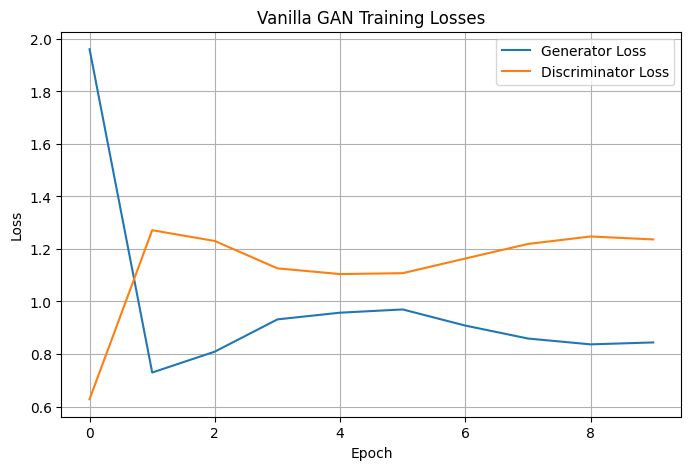

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(generator_losses, label="Generator Loss")
plt.plot(discriminator_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Vanilla GAN Training Losses")
plt.legend()
plt.grid(True)
plt.show()

## 12. Generate Final Synthetic Images

The trained Generator can now create new synthetic digit images from random noise.

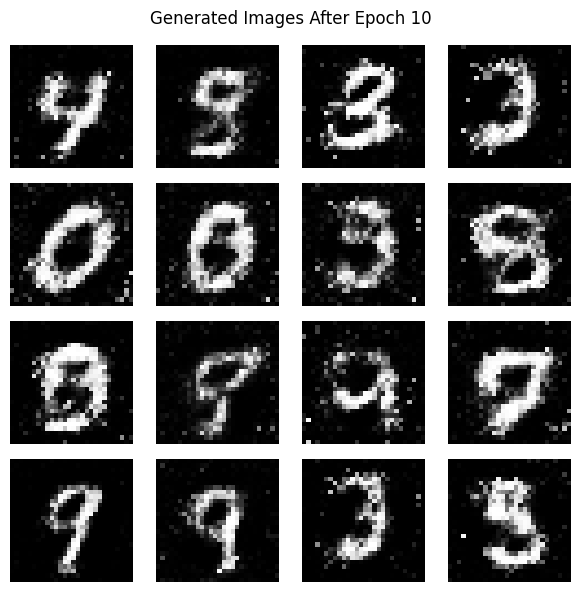

In [15]:
# Generate a fresh batch of random noise vectors.
new_noise = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, LATENT_DIM])

# Display the final generated digit images.
display_generated_images(generator, EPOCHS, new_noise)

## Conclusion

This notebook implemented a Vanilla GAN for generating handwritten digit images using the MNIST dataset. The Generator learned to convert random noise into synthetic image vectors, while the Discriminator learned to classify images as real or generated.

The implementation demonstrates the core GAN training loop: generate fake samples, evaluate real and fake samples with the Discriminator, update the Discriminator, and then update the Generator based on how well it fools the Discriminator.

For higher-quality images, the same workflow can be extended with more training epochs, convolutional layers, improved loss functions, or more advanced GAN variants such as DCGAN or WGAN.